In [1]:
import numpy as np, pickle, sys, matplotlib as mpl, pickle, os
import matplotlib.pyplot as plt, matplotlib.colors as colors
from matplotlib import ticker, cm

FUKA_path = os.getenv('HOME')+'/lib/fuka'
pyFUKA_path = FUKA_path+'/codes/PythonTools'
pyFUKA_libspath = pyFUKA_path+'/lib/'
sys.path.append(pyFUKA_libspath)
os.environ["HOME_KADATH)"] = FUKA_path
%env HOME_KADATH=$FUKA_path

env: HOME_KADATH=/home/tootle/lib/fuka


In [2]:
from fuka_plot_tools.setup_utils import get_reader

In [3]:
interp_var= "gxx"
data_base_path="/home/tootle/lib/falcon_data"
# initial_data_path=pyFUKA_path+'/Example_id/converged_NS_TOTAL_BC.togashi.2.23.-0.4.0.11.dat'
# initial_data_path=data_base_path+"/NS_ISO_UNIFORM_ROT.gam2.madm.1.4.omega.0.0.09.dat"
initial_data_path=data_base_path+"/NS_ISO_UNIFORM_ROT.gam2.madm.1.4.chi.0.2.0.17.dat"
if os.path.isfile(initial_data_path) == True:
    readerISO = get_reader(initial_data_path, ns_iso_uniformrot=True)
else:
    print("{} not found",initial_data_path)

g11: 

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::pair<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, Kadath::quantity_type> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for Kadath::Tensor already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for Kadath::Scalar already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for Kadath::Vector already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for ns_isotropic_reader_t already registered; second conversion method ignored.


1.99652, g22: 0.49913, g33: 0.499084


In [4]:
initial_data_path=data_base_path+"/NS_TOTAL_BC.gam2.madm.1.4.chi.0.0.09.dat"
# initial_data_path=data_base_path+"/NS_TOTAL_BC.gam2.madm.1.4.chi.0.2.0.09.dat"
print(initial_data_path)
if os.path.isfile(initial_data_path) == True:
    readerNS = get_reader(initial_data_path, ns=True)
else:
    print("{} not found",initial_data_path)

/home/tootle/lib/falcon_data/NS_TOTAL_BC.gam2.madm.1.4.chi.0.0.09.dat


In [5]:
readerISO.getExporterKeys()

['beta1',
 'beta2',
 'beta3',
 'eps',
 'g11',
 'g12',
 'g13',
 'g22',
 'g23',
 'g33',
 'k11',
 'k12',
 'k13',
 'k22',
 'k23',
 'k33',
 'lapse',
 'press',
 'rho',
 'vel1',
 'vel2',
 'vel3']

In [6]:
y1, y2 = [-30, 30]
npts = 256

y_coords = np.linspace(y1, y2, num=npts)

x1, x2 = [-30,30]
x_coords = np.linspace(x1, x2, num=npts)

coords_lst = [[x,y] for y in y_coords for x in x_coords]

In [7]:
dataISO = readerISO.getFieldValues("cA", coords_lst, -1)

In [8]:
data = np.abs(np.array(dataISO))

In [9]:
data=data.reshape(len(x_coords),len(x_coords))

In [10]:
X, Y = np.meshgrid(x_coords, y_coords)

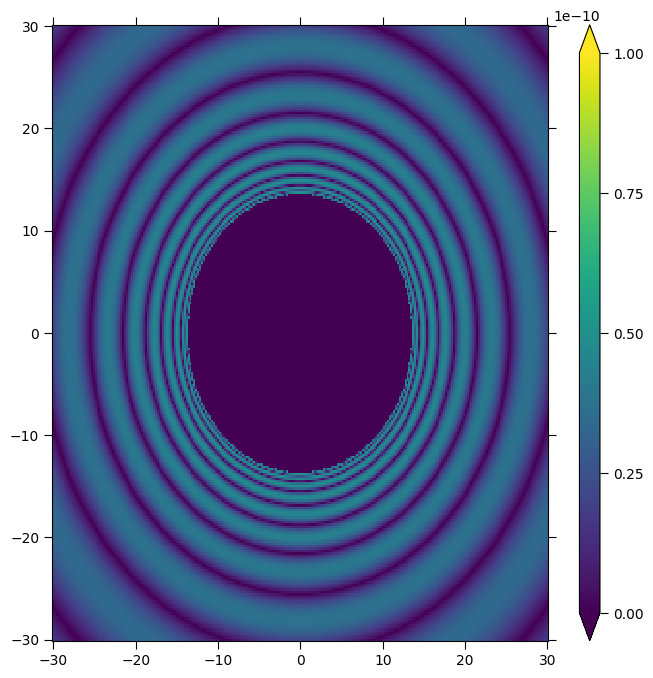

In [11]:
norm = colors.Normalize(vmin=1e-15, vmax=1e-10, clip=False)
fig, axs = plt.subplots(1,1)
cs = axs.pcolor(X, Y, data, norm=norm)
cbarax,kw = mpl.colorbar.make_axes(axs, location='right', orientation='vertical', aspect=30)
cbar = fig.colorbar(
        cs,
        cax=cbarax, ticklocation='right',
        orientation='vertical', extend='both',
        ticks=np.linspace(norm.vmin, norm.vmax, num=5)
      )

for v in dataISO:
    if np.isnan(v.any()):
        print(v)

dataNS = readerNS.getExporterFieldValues(interp_var, coords_lst)
dataNS = np.array(dataNS)
dataNS = dataNS.reshape(npts,npts)

X, Y = np.meshgrid(x_coords, y_coords)

norm = None 
# norm = colors.LogNorm(vmin=1e-10, vmax = 1e-2, clip=False) 
norm = colors.Normalize(vmin=1.3, vmax = 2, clip=False) 

plt.rcParams.update({
'figure.figsize'    : [8.0 * 2, 4],
'image.cmap' : 'inferno'
})
fig,axs = plt.subplots(1,2)
cs=axs[0].pcolor(X, Y, dataISO, norm=norm)
axs[1].pcolor(X, Y, dataNS, norm=norm)
cbarax,kw = mpl.colorbar.make_axes(axs, location='right', orientation='vertical', aspect=30)
cbar = fig.colorbar(
        cs,
        cax=cbarax, ticklocation='right',
        orientation='vertical', extend='both',
        ticks=np.linspace(norm.vmin, norm.vmax, num=5)
      )

In [12]:
vals = readerISO.getallExporterFieldValues__cartesian_pointwise([0., 0., 0.])

g11: 2.00219, g22: 2.00219e-24, g33: 2.00198e-24


In [13]:
def detgij(vals):
    return vals["g11"] * vals["g22"] * vals["g33"] \
    + vals["g12"] * vals["g23"] * vals["g13"] \
    + vals["g13"] * vals["g12"] * vals["g23"] \
    - vals["g13"] * vals["g22"] * vals["g13"] \
    - vals["g12"] * vals["g12"] * vals["g33"] \
    - vals["g11"] * vals["g23"] * vals["g23"]

In [14]:
detgij(vals)

8.025427709650991

In [15]:
for i in np.linspace(0,20, num=64):
    x = 0.
    y = 0.
    z = i
    r = np.sqrt(x**2 + y**2 +z**2)
    vals = readerISO.getallExporterFieldValues__cartesian_pointwise([x,y,z])
    print(r,detgij(vals), vals["g11"] , vals["g22"] , vals["g33"],
          vals["g12"] * vals["g13"] * vals["g23"])

0.0g11:  8.025427709650991 2.002187101441656 2.0019760087285223 2.002187101441656 -0.0
0.31746031746031744 7.997163878430061 1.9998339113415795 1.999623070530525 1.999833911341579 -0.0
0.6349206349206349 7.913502791980579 1.992835796803238 1.9926257051611982 1.9928357968032377 -0.0
0.9523809523809523 7.7777338633910444 1.9813732125843335 1.9811643481834555 1.9813732125843335 0.0
1.2698412698412698 7.595016140435355 1.9657343472889162 1.9655271575480628 1.965734347288916 -0.0
1.5873015873015872 7.371945674288197 1.9462978311550616 1.9460927232210636 1.9462978311550614 -0.0
1.9047619047619047 7.116041895271278 1.9235113461248052 1.9233086795300443 1.923511346124805 0.0
2.2222222222222223 6.835219842375503 1.8978683321724212 1.897668413971294 1.8978683321724212 0.0
2.5396825396825395 6.537307123657743 1.8698849043314831 1.869687986693321 1.869884904331483 -0.0
2.8571428571428568 6.22964786508343 1.8400787398846026 1.8398850199334007 1.8400787398846026 0.0
3.1746031746031744 5.918815843844

In [16]:
print(vals)

{'beta1': 0.0, 'beta2': -1.5853339286791409e-13, 'beta3': 0.0, 'eps': 0.0, 'g11': 1.1474764609096855, 'g12': 0.0, 'g13': 0.0, 'g22': 1.147363498199199, 'g23': 0.0, 'g33': 1.1474764609096855, 'k11': 0.0, 'k12': 1.3586312232783099e-24, 'k13': 0.0, 'k22': 0.0, 'k23': 1.35863122327831e-14, 'k33': 0.0, 'lapse': 0.9324516523426265, 'press': 0.0, 'rho': 0.0, 'vel1': 0.0, 'vel2': 1.9972684080409802e-11, 'vel3': 0.0}
